In [1]:
import pybamm # loads pybamm package
import matplotlib.pyplot as plt # package for plotting
import numpy as np # for arrays
import pandas as pd # for structure use .csv for importing and exporting
import math # log, sin, exp
from scipy.integrate import solve_ivp # integration, used in accelerated simulation
from datetime import datetime
import pickle # for saving simulations
from pybamm import exp, constants
from scipy.optimize import least_squares
from scipy.optimize import minimize
from scipy.signal import savgol_filter
import gzip
import time
import optuna
import openpyxl
#import galvani
from galvani import res2sqlite
import sqlite3

#/home/siegeljb/.local/sundials/

# export SUNDIALS_DIR=/home/siegeljb/.local/sundials/
%matplotlib ipympl

In [2]:
#data = pd.read_excel("V:\\PROJ_GMJULY2022\\Cycler_Data_By_Cell\\GMJuly2022_CELL041\\GMJuly2022_CELL041_RPT_1_P25C_5P0PSI_20221007_R0_CH017_20221007163327_36_3_1_2818579453.xlsx",sheet_name='record')
# data = pd.read_excel("/home/siegeljb/Lab_share_Volt/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL041/GMJuly2022_CELL041_RPT_1_P25C_5P0PSI_20221007_R0_CH017_20221007163327_36_3_1_2818579453.xlsx",sheet_name='record')

In [4]:
prefix='/home/siegeljb/Lab_share_Volt/PROJ_GMJULY2022/Cycler_Data_By_Cell/'
# #Exp_data=pd.read_csv('/home/siegeljb/Lab_share_Volt/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL901/GMJuly2022_CELL901REF_RPT_3_P25C_P5P0PSI_20230228_R3_AuxDat_TC40_20230307_175747.csv', sep='\t',skiprows=[0,1,2,3,5],header=0)
Exp_data=pd.read_csv('GMJuly2022_CELL901/GMJuly2022_CELL901REF_RPT_3_P25C_P5P0PSI_20230228_R1_AuxDat_TC40_20230228_164816.csv', sep='\t',skiprows=[0,1,2,3,5],header=0)

# #,header=4) 
# #, skiprows=[1]
res_file = [r'GMJuly2022_CELL901/GMJuly2022_CELL901REF_RPT_3_P25C_P5P0PSI_20230228_R1.res', 
            r'GMJuly2022_CELL901/GMJuly2022_CELL901REF_RATE_1_P25C_P5P0PSI_20230302_R1.res']
#              /home/siegeljb/Lab_share_Volt/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL901/GMJuly2022_CELL901REF_RPT_3_P25C_P5P0PSI_20230228_R1.res
#Exp_data=pd.read_csv('/home/siegeljb/Lab_share_Volt/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL901/GMJuly2022_CELL901REF_RPT_1_P25C_P5P0PSI_20230222_R0_AuxDat_TC40_20230222_133638.csv', sep='\t',skiprows=[0,1,2,3,5],header=0)
#res_file = r'/home/siegeljb/Lab_share_Volt/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL901/GMJuly2022_CELL901REF_RPT_1_P25C_P5P0PSI_20230222_R0.res'

# sqlite_file = '/home/siegeljb/Lab_share_Volt/PROJ_GMJULY2022/Cycler_Data_By_Cell/GMJuly2022_CELL901/GMJuly2022_CELL901REF_RPT_3_P25C_P5P0PSI_20230228_R1.s3db'
# #res_file = os.path.join(testdata_dir, basename + '.res')
# #sqlite_file = os.path.join(str(tmpdir), basename + '.s3db')
# res2sqlite.convert_arbin_to_sqlite(res_file, sqlite_file)
# assert os.path.isfile(sqlite_file)
# with sqlite3.connect(sqlite_file) as conn:
#     csr = conn.execute('SELECT * FROM Channel_Normal_Table;')
#     csr.fetchone()

import cellpy
c = cellpy.get(res_file, mass=1)
# from galvani import BioLogic
# import pandas as pd

# mpr_file = BioLogic.MPRfile('test.mpr')
# df = pd.DataFrame(mpr_file.data)


In [5]:
#print(c.get_summary())
print(c.data.raw.head())
list(c.data.raw)

   test_id  data_point  test_time  step_time                  date_time  \
0        1           1   1.065940   1.005653 2023-02-28 16:48:33.000001   
1        1           2   2.079671   2.019384 2023-02-28 16:48:34.000000   
2        1           3   3.082309   3.022022 2023-02-28 16:48:35.000000   
3        1           4   4.087264   4.026977 2023-02-28 16:48:36.000000   
4        1           5   5.088231   5.027944 2023-02-28 16:48:37.000000   

   step_index  cycle_index  is_fc_data   current   voltage  charge_capacity  \
0           7            1           0  0.175167  3.847293         0.000049   
1           7            1           0  0.174806  3.847780         0.000098   
2           7            1           0  0.175167  3.848266         0.000147   
3           7            1           0  0.174806  3.848428         0.000196   
4           7            1           0  0.174806  3.848591         0.000244   

   discharge_capacity  charge_energy  discharge_energy     dv_dt  \
0     

['test_id',
 'data_point',
 'test_time',
 'step_time',
 'date_time',
 'step_index',
 'cycle_index',
 'is_fc_data',
 'current',
 'voltage',
 'charge_capacity',
 'discharge_capacity',
 'charge_energy',
 'discharge_energy',
 'dv_dt',
 'internal_resistance',
 'ac_impedance',
 'aci_phase_angle']

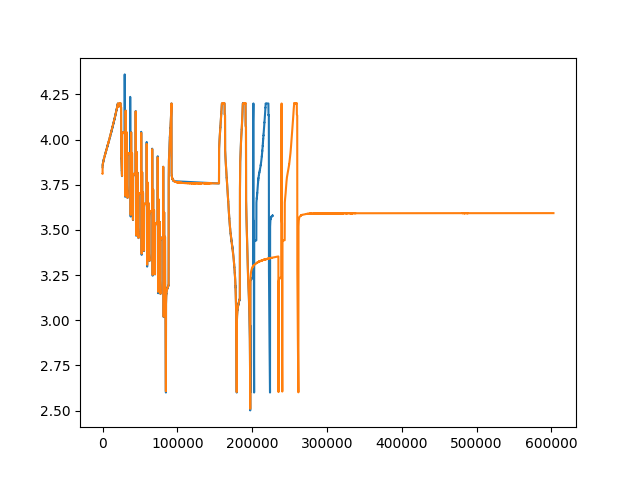

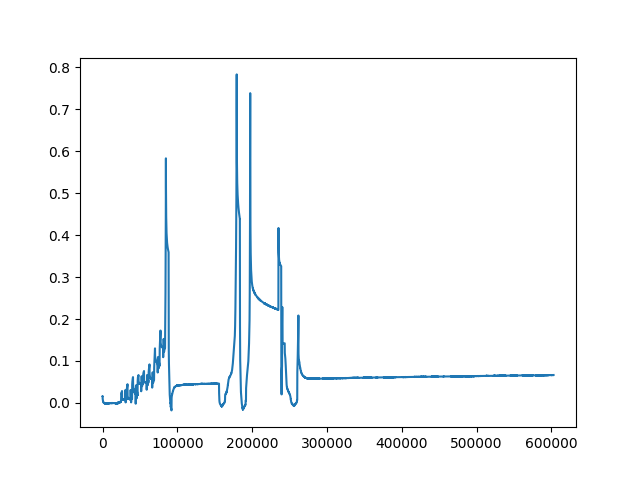

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


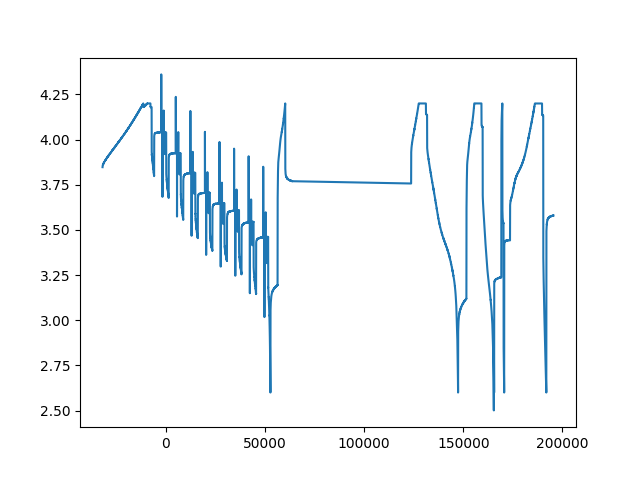

In [6]:
# from cellpy import cellreader
raw_cycler_data=c.data.raw
# d = cellreader.CellpyCell().from_raw(res_file)
# d.set_mass(1)
# d.make_step_table()
# d.make_summary()

start_time_exp=Exp_data["Timestamp"][0]/1000 # epoch time time in ms and convert to s
start_time_arbin=raw_cycler_data["date_time"].iloc[0].value/1e9+3600*4-1855 # UTC offset for EST, need to also be cognizent of DST?

# summary = d.data.summary
# print(raw_cycler_data.head())
# print(Exp_data.head())
fig, ax = plt.subplots(1, 1)
ax.plot(raw_cycler_data["test_time"],raw_cycler_data["voltage"],Exp_data["Test Time"]+start_time_exp-start_time_arbin,Exp_data["Potential"])
plt.show()

fig, ax = plt.subplots(1, 1)
ax.plot(Exp_data["Test Time"]+start_time_exp-start_time_arbin,3.345+0.0007-Exp_data["Vneg"])
plt.show()

# import cellpy.utils.ica as ica

# dqdv = ica.dqdv_frames(c, cycle=[1, 10, 100], voltage_resolution=0.01)


timtot=raw_cycler_data["test_time"]
find_dupe_times=timtot.duplicated(keep='first')
timtot[find_dupe_times]=timtot[find_dupe_times]+2e-3
find_dupe_times2=timtot.duplicated(keep='first')
tstart=32000
#tstart=163648 #C/4 discharge

t_simF=timtot.to_numpy().flatten()-tstart
interp_voltageF=(raw_cycler_data["voltage"].values).flatten()
interp_currentF=(raw_cycler_data["current"].values).flatten()
print(type(t_simF))

print(type(interp_currentF))
fig, ax = plt.subplots(1, 1)
ax.plot(t_simF,interp_voltageF)
plt.show()




In [ ]:
# with gzip.open('/home/siegeljb/Lab_share_Volt/PROJ_GMJULY2022/GM_Fit/GMJuly2022_CELL041_RPT_1_P25C_5P0PSI_20221007_R0_CH017_20221007163327_36_3_1_2818579453.pkz', 'wb') as f:
#    pickle.dump(data,f)


# with gzip.open('/home/siegeljb/Lab_share_Volt/PROJ_GMJULY2022/GM_Fit/GMJuly2022_CELL041_RPT_1_P25C_5P0PSI_20221007_R0_CH017_20221007163327_36_3_1_2818579453.pkz', 'rb') as f:
#    data=pickle.load(f)

# data.head()
# timtot=pd.to_timedelta(data["Total Time"] ).dt.total_seconds().copy()
# find_dupe_times=timtot.duplicated(keep='first')
# timtot[find_dupe_times]=timtot[find_dupe_times]+2e-3
# find_dupe_times2=timtot.duplicated(keep='first')
# tstart=16100
# t_simF=timtot.values-tstart
# interp_voltageF=data["Voltage(V)"].values
# interp_currentF=data["Current(A)"].values

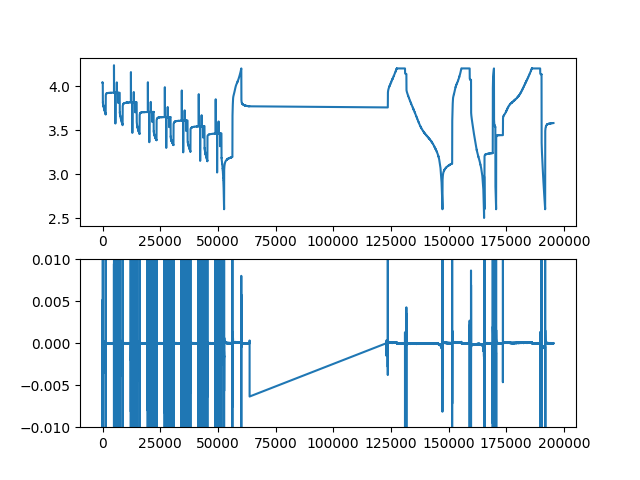

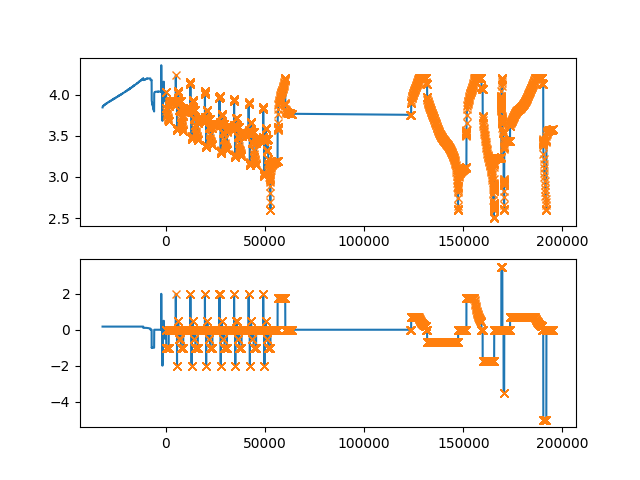

In [7]:

# a=t_sim[0]
# print(a)

# t=t_simF
# dt=1000
# mean_dt=np.mean(np.diff(t))
# dt_changes=(t % (dt/mean_dt))<=mean_dt

def downsample_data(t,i,v,dv,di,dt):
    # mean_dt=np.mean(np.diff(t))
    # dt_changes=(t % (dt/mean_dt))<=mean_dt

    deriv_V=savgol_filter(v,20,3,deriv=1)/np.diff(t, prepend=0)
    fig,ax = plt.subplots(2,1)
    ax1 = ax.flat[0]
    ax1.plot(t,v)
    ax2 = ax.flat[1]
    ax2.plot(t,deriv_V)
    ax2.set_ylim([-.01, .01])
    #ax2.plot(t_sim,interp_current,'x')
    plt.show()

    dv_changes=abs(deriv_V)>dv
    #dv_changes=(np.abs(np.diff(v, prepend=0)/np.diff(t, prepend=0))>dv) + (np.abs(np.diff(v, append=0)/np.diff(t, append=0))>dv)
    di_changes=(np.abs(np.diff(i, prepend=0)/np.diff(t, prepend=0))>di) + (np.abs(np.diff(i, append=0)/np.diff(t, append=0))>di)
    dt_changes=t<0
    Tlast=0
    for ii in range(len(t)):
        if(t[ii]>=Tlast+dt):
            Tlast=t[ii]
            dt_changes[ii]=True

    index=dt_changes + dv_changes + di_changes

    t_ds=t[index]
    i_ds=i[index]
    v_ds=v[index]
    return t_ds,i_ds,v_ds

t_sim,interp_current,interp_voltage=downsample_data(t_simF[t_simF>=0],interp_currentF[t_simF>=0],interp_voltageF[t_simF>=0],2e-3,.5,100)
fig,ax = plt.subplots(2,1)
# plt.title(str(cells[i]) + "Input Data")

#%matplotlib ipympl
ax1 = ax.flat[0]
ax1.plot(t_simF,interp_voltageF)
ax1.plot(t_sim,interp_voltage,'x')
ax2 = ax.flat[1]
ax2.plot(t_simF,interp_currentF)
ax2.plot(t_sim,interp_current,'x')

plt.show()

In [3]:
# Parameter Definitions

# cathode diffusion
def NMC_diffusivity_Siegel(sto, T):
    D_ref = pybamm.InputParameter("posDiffusion")
    E_D_s = 18550
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref * arrhenius

# anode diffusion
def graphite_diffusivity_Siegel(sto, T):
    D_ref = pybamm.InputParameter("negDiffusion")
    E_D_s = 42770
    arrhenius = exp(E_D_s / constants.R * (1 / 298.15 - 1 / T))
    return D_ref * arrhenius

# cathode kinetics
def NMC_electrolyte_exchange_current_density_Siegel(c_e, c_s_surf, c_s_max, T):
    m_ref = pybamm.InputParameter("posKinetics")
    E_r = 39570
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
    return (
        m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5
    )

# anode kinetics
def graphite_electrolyte_exchange_current_density_Siegel(c_e, c_s_surf, c_s_max, T):
    m_ref = pybamm.InputParameter("negKinetics")
    E_r = 37480
    arrhenius = exp(E_r / constants.R * (1 / 298.15 - 1 / T))
    return (m_ref * arrhenius * c_e**0.5 * c_s_surf**0.5 * (c_s_max - c_s_surf) ** 0.5)

def electrolyte_diffusivity_Dix(c_e, T):
    """
    Diffusivity of LiPF6 in EC:EMC vol 3:7 with 2 wt% VC as a function of
    ion concentration.
    The original data is from [1]. The Fitting Funciton is from [2]

    References
    ----------
    .. [1]  Sean T. Dix et al. "Leveraging Molecular Dynamics to Improve Porous
    Electrode Theory Modeling Predictions of Lithium-Ion Battery Cells." 2023
    J. Electrochem. Soc. 170 083503
    DOI 10.1149/1945-7111/aceca8
       [2] Lars Ole Valøen and Jan N. Reimers. "Transport Properties of LiPF6-Based
       Li-Ion Battery Electrolytes." 2005 J. Electrochem. Soc. 152 A882 Parameters
    ----------
    c_e: :class:`pybamm.Symbol`
        Dimensional electrolyte concentration
    T: :class:`pybamm.Symbol`
        Dimensional temperature


    Returns
    -------
    :class:`pybamm.Symbol`
        Electrolyte diffusivity
    """

    # Diffusivity in 10E-10 m^2/s = 0.0001*10^((D00+ D01 / (T -
    # ((Tg0 + Conc * Tg1))))+ (D10+ D11/ (T - ((Tg0 + Conc* Tg1)))) * Conc)
    # Where Conc is in units of M and T is in K

    D00 = -487.2
    D01 = -28530000
    Tg0 = 58320
    Tg1 = 50.31
    D10 = -52.79
    D11 = -3061000
    c_e_M = c_e / 1000
    D_c_e = (
        (10**-10)
        * 0.0001
        * 10
        ** (
            (D00 + D01 / (T - ((Tg0 + c_e_M * Tg1))))
            + (D10 + D11 / (T - ((Tg0 + c_e_M * Tg1)))) * c_e_M
        )
    )

    return D_c_e*pybamm.InputParameter("electDiff")


def electrolyte_conductivity_Dix(c_e, T):
    """
    Conductivity of LiPF6 in 3:7 EC:DMC as a function of ion concentration. The original
    data is from [1].

    References
    ----------
    ..     .. [1]  Sean T. Dix et al. "Leveraging Molecular Dynamics to Improve
    Porous Electrode Theory Modeling Predictions of Lithium-Ion Battery Cells."
    2023 J. Electrochem. Soc. 170 083503 DOI 10.1149/1945-7111/aceca8.

    Parameters
    ----------
    c_e: :class:`pybamm.Symbol`
        Dimensional electrolyte concentration
    T: :class:`pybamm.Symbol`
        Dimensional temperature


    Returns
    -------
    :class:`pybamm.Symbol`
        Electrolyte conductivity
    """
    k_Kmax = 3.58e-7
    k_Cmax = 4.84e-6
    k_a = 0.4793
    k_P2 = -0.3299
    k_P1 = 2.22e-14
    k_Ea = 13490
    k_Rg = 8.314
    k_T0 = 162.5
    # Conductivity in mS/cm = 1000*(k_Kmax* (Conc / K_Cmax) ^ k_a *
    # EXP(k_P2 * (Conc – k_Cmax) ^ 2 – k_P1 * (Conc- K_Cmax) / K_Cmax)
    # * EXP(-k_Ea / k_Rg * (1 / T - 1 / K_T0)))
    # Where Conc is in units of M and T is in K
    # convert to S/m
    c_e_M = c_e / 1000

    sigma_e = 100 * (
        k_Kmax
        * (c_e_M / k_Cmax) ** k_a
        * pybamm.exp(k_P2 * (c_e_M - k_Cmax) ** 2 - k_P1 * (c_e_M - k_Cmax) / k_Cmax)
        * pybamm.exp(-k_Ea / k_Rg * (1 / T - 1 / k_T0))
    )

    return sigma_e*pybamm.InputParameter("electCond")


In [4]:
def JS_Get_xy_from_voltage(parameter_values,initial_voltage):
    # First we solve for x_100 and y_100
    param = pybamm.LithiumIonParameters()
    Vmin = 2.8
    Vmax = 4.2
    Q_n = parameter_values.evaluate(param.n.Q_init)
    Q_p = parameter_values.evaluate(param.p.Q_init)
    Q_Li = parameter_values.evaluate(param.Q_Li_particles_init)
    print(Q_n)
    print(Q_p)
    print(Q_Li)

    U_n = param.n.prim.U
    U_p = param.p.prim.U
    T_ref = param.T_ref

    model = pybamm.BaseModel()

    x_100 = pybamm.Variable("x_100")
    y_100 = (Q_Li - x_100 * Q_n) / Q_p

    y_100_min = 1e-10

    x_100_upper_limit = (Q_Li - y_100_min*Q_p)/Q_n
    print(x_100_upper_limit)
    model.algebraic = {x_100: U_p(y_100, T_ref) - U_n(x_100, T_ref) - Vmax}

    model.initial_conditions = {x_100: x_100_upper_limit}

    model.variables = {
        "x_100": x_100,
        "y_100": y_100
    }

    sim = pybamm.Simulation(model, parameter_values=parameter_values)
    sol = sim.solve([0])

    x_100 = sol["x_100"].data[0]
    y_100 = sol["y_100"].data[0]

    for var in ["x_100", "y_100"]:
        print(var, ":", sol[var].data[0])

    # Based on the calculated values for x_100 and y_100 we solve for x_0
    model = pybamm.BaseModel()

    x_0 = pybamm.Variable("x_0")
    Q = Q_n * (x_100 - x_0)
    y_0 = y_100 + Q/Q_p

    model.algebraic = {x_0: U_p(y_0, T_ref) - U_n(x_0, T_ref) - Vmin}
    model.initial_conditions = {x_0: 0.1}

    model.variables = {
        "Q": Q,
        "x_0": x_0,
        "y_0": y_0,
    }

    sim = pybamm.Simulation(model, parameter_values=parameter_values)
    sol = sim.solve([0])
    Q=sol["Q"].data[0]

    for var in ["Q", "x_0", "y_0"]:
        print(var, ":", sol[var].data[0])


    # Given x_100, y_100 and Q, solve for initial stored charge to get the right voltage
    Q_init = pybamm.Variable("Q_init")
    #Q = Q_n * (x_100 - x_0)
    #y_0 = y_100 + Q/Q_p

    model.algebraic = {Q_init: U_p(y_100-(Q_init-Q)/Q_p, T_ref) - U_n(x_100+(Q_init-Q)/Q_n, T_ref) - initial_voltage}
    model.initial_conditions = {Q_init: Q}

    model.variables = {
        "Q_init": Q_init,
    }

    sim = pybamm.Simulation(model, parameter_values=parameter_values)
    sol = sim.solve([0])


    for var in ["Q_init"]:
        print(var, ":", sol[var].data[0])
    Q_init=sol["Q_init"].data[0]
    return Q_init, x_100+(Q_init-Q)/Q_n, y_100-(Q_init-Q)/Q_p

In [6]:
#parameter_values = pybamm.ParameterValues("Siegel2022")
import Siegel2022
param_dict = Siegel2022.get_parameter_values()
#param_dict = {"a": 1, "b": 2, "c": 3}
parameter_values = pybamm.ParameterValues(param_dict)   
print(f"parameter values are {parameter_values}")

parameter_values.update(
    {
        "Negative electrode active material volume fraction": 0.66735,
        "Positive electrode active material volume fraction": 0.70513,
    #    "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
    #    "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
        "Initial temperature [K]": 273.15+25,
        "Ambient temperature [K]": 273.15+25,
        "Lower voltage cut-off [V]": 2.7, 
        "Upper voltage cut-off [V]": 4.35
    },check_already_exists=False,)

q_init, x_init, y_init=JS_Get_xy_from_voltage(parameter_values,4)
print(q_init)
print(x_init)
print(y_init)

KeyError: "must provide 'cell' parameters for lithium_ion chemistry"

3.4108044532996846
4.202506606993028
Q_init : 2.6249793647626576
19353.0848
13218.121826086957
0.6557731921694795
0.3906957902689875
18850.856182103857
13822.817059716777


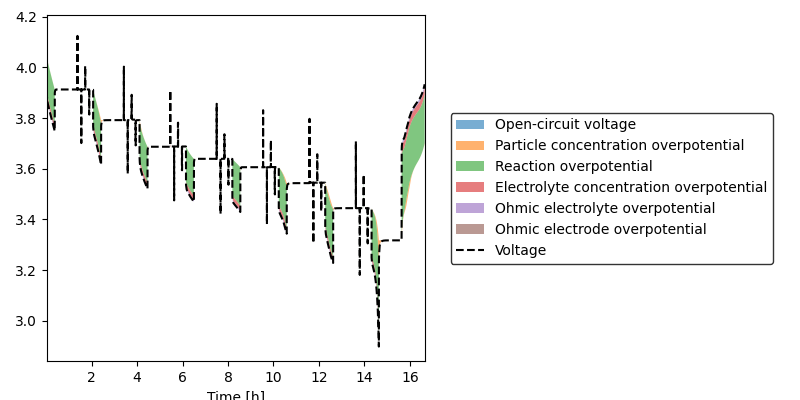

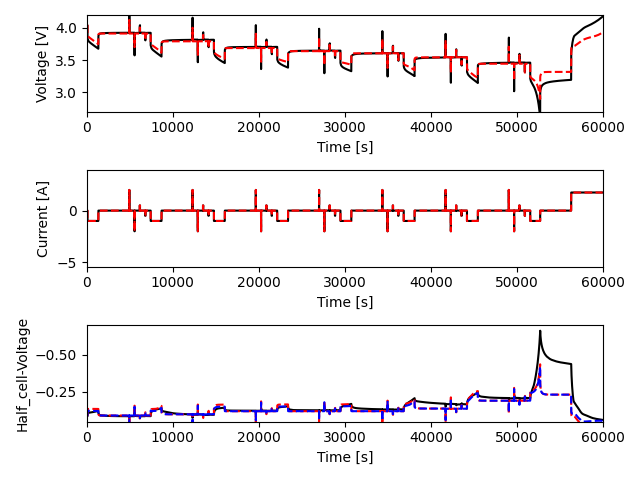

Checking Voltage lengths for RMSE:  2596 3812 RMSE (mV) : 83.43286148549622


In [11]:
#parameter_values = pybamm.ParameterValues("Siegel2022")
spme = pybamm.lithium_ion.SPMe()
#spme = pybamm.lithium_ion.DFN()

#pybamm.print_parameters(parameter_values,outputfile="Siegel2022P.txt")

param0 = 0.5*6.748678940622972e-14
param1 = 4*1.0122133310725916e-14
param2 = 0.25*1.3715539078341868e-07
param3 = 1.2178795378580133e-06


param = spme.param


#print(parameter_values)

# parameter_values.update(
#     {
#         "Maximum concentration in positive electrode [mol.m-3]":	31927.3,
#         "Maximum concentration in negative electrode [mol.m-3]":	29637,
#         },check_already_exists=False,)    

Cap=3.5
x_100=0.867
y_100=0.3083
initial_soc=0.9

C_n_init = 4.0458 
C_p_init = 5.4828

#Cell 901 update
Cap=3.004
x_100=0.74
y_100=0.3083
C_n_init = 4.5 
C_p_init = 4.6

x_0=x_100-Cap/C_n_init
y_0=y_100+Cap/C_p_init
x = x_0 + initial_soc * (x_100 - x_0)
y = y_0 - initial_soc * (y_0 - y_100)

x_init = x # 0.861
y_init = y # 0.3083
eps_n_init = parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
eps_p_init = parameter_values.evaluate(C_p_init*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
cs_n_init = parameter_values.evaluate(x_init* param.n.prim.c_max)
cs_p_init = parameter_values.evaluate(y_init* param.p.prim.c_max)

# print(parameter_values.evaluate(param.n.L))
# print(parameter_values.evaluate(param.n.prim.c_max ))
# print(parameter_values.evaluate(param.A_cc))

#U_p = param.p.prim.U
# sto_p=cs_p_init/parameter_values.evaluate(param.p.prim.c_max)
# print(sto_p)
# print(parameter_values.evaluate(U_p(sto_p,273.15+25)))

#U_n = param.n.prim.U
# sto_n=cs_n_init/parameter_values.evaluate(param.n.prim.c_max)
# print(sto_n)
# print(parameter_values.evaluate(U_n(sto_n,273.15+25)))


# Updating parameters for initialization
parameter_values.update(
    {
        "Negative electrode active material volume fraction": eps_n_init,
        "Positive electrode active material volume fraction": eps_p_init,
        "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
        "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
        "Initial temperature [K]": 273.15+25,
        "Ambient temperature [K]": 273.15+25,
        "Lower voltage cut-off [V]": 2.4, 
        "Upper voltage cut-off [V]": 4.35
    },check_already_exists=False,)

#initial_voltage_string="4.1 V"
#print(interp_voltage[0])
#[xinitV,yinitV]=pybamm.lithium_ion.get_initial_stoichiometries(str(interp_voltage[0]) +' V',parameter_values)

# Given x_100, y_100 and Q, solve for initial stored charge to get the right voltage
initial_voltage=interp_voltage[0]
model_initV = pybamm.BaseModel()
param_initV = pybamm.LithiumIonParameters()
# Vmin = 2.8
# Vmax = 4.2
# Q_n = parameter_values.evaluate(param.n.Q_init)
# Q_p = parameter_values.evaluate(param.p.Q_init)
# Q_Li = parameter_values.evaluate(param.Q_Li_particles_init)
# print(Q_n)
# print(Q_p)
# print(Q_Li)

U_n = param_initV.n.prim.U
U_p = param_initV.p.prim.U
T_ref = param_initV.T_ref
Q_init=0
a0=y_100-(Q_init-Cap)/C_p_init
a1=x_100+(Q_init-Cap)/C_n_init
Vmin_init=parameter_values.evaluate(U_p(y_100-(Q_init-Cap)/C_p_init, T_ref) - U_n(x_100+(Q_init-Cap)/C_n_init, T_ref))
Q_init=Cap
a2=y_100-(Q_init-Cap)/C_p_init
a3=x_100+(Q_init-Cap)/C_n_init
Vmax_init=parameter_values.evaluate(U_p(y_100-(Q_init-Cap)/C_p_init, T_ref) - U_n(x_100+(Q_init-Cap)/C_n_init, T_ref))

print(Vmin_init)
print(Vmax_init)

Q_init = pybamm.Variable("Q_init")
#Q = Q_n * (x_100 - x_0)
#y_0 = y_100 + Q/Q_p
#T_ref=273.15+25
model_initV.algebraic = {Q_init: U_p(y_100-(Q_init-Cap)/C_p_init, T_ref) - U_n(x_100+(Q_init-Cap)/C_n_init, T_ref) - initial_voltage}
model_initV.initial_conditions = {Q_init: Cap}
model_initV.variables = {
    "Q_init": Q_init,
}

sim = pybamm.Simulation(model_initV, parameter_values=parameter_values)
sol = sim.solve([0])
for var in ["Q_init"]:
    print(var, ":", sol[var].data[0])
Q_init=sol["Q_init"].data[0]

xinitV=x_100+(Q_init-Cap)/C_n_init
yinitV=y_100-(Q_init-Cap)/C_p_init
print(cs_n_init)
print(cs_p_init)
print(xinitV)
print(yinitV)

cs_n_init = parameter_values.evaluate(xinitV* param.n.prim.c_max)
cs_p_init = parameter_values.evaluate(yinitV* param.p.prim.c_max)
print(cs_n_init)
print(cs_p_init)

#q_init,xinitV,yinitV=JS_Get_xy_from_voltage(parameter_values,interp_voltage[0])
#print(q_init)
parameter_values.update(
    {
        "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
        "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
    },check_already_exists=False,)

t_end=1400
t_end=8000
t_end=60000

#current_interpolant = pybamm.Interpolant(t_sim, -interp_current, pybamm.t)
current_interpolant = pybamm.Interpolant(t_sim[(t_sim>=0) * (t_sim<t_end)], -interp_current[(t_sim>=0) * (t_sim<t_end)], pybamm.t)

parameter_values["Current function [A]"] = current_interpolant
parameter_values.update(
    {
        "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_Siegel,
        "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_Siegel,
        "Positive electrode exchange-current density [A.m-2]": NMC_electrolyte_exchange_current_density_Siegel,
        "Negative electrode exchange-current density [A.m-2]": graphite_electrolyte_exchange_current_density_Siegel,
        "Electrolyte diffusivity [m2.s-1]": electrolyte_diffusivity_Dix,
        "Electrolyte conductivity [S.m-1]": electrolyte_conductivity_Dix,
        "Cation transference number": 0.25,
        "Separator porosity": 0.2,
        "Positive electrode porosity": 0.2,
        "Negative electrode porosity": 0.15,
        })           



var_pts = {"x_n": 30, "x_s": 30, "x_p": 30, "r_n": 40, "r_p": 40}

submesh_types = spme.default_submesh_types
submesh_types["negative particle"] = pybamm.MeshGenerator(
    pybamm.Exponential1DSubMesh, submesh_params={"side": "right"}
)
submesh_types["positive particle"] = pybamm.MeshGenerator(
    pybamm.Exponential1DSubMesh, submesh_params={"side": "right"}
)


#fast_solver = pybamm.ScikitsDaeSolver(atol=1e-7, rtol=1e-7) #,mode="fast" ,dt_max=.1
fast_solver=pybamm.CasadiSolver(atol=1e-7, rtol=1e-7 ,mode="safe" ,dt_max=50)

sim_0 = pybamm.Simulation(spme, parameter_values=parameter_values, solver=fast_solver ,   var_pts=var_pts,
    submesh_types=submesh_types,)

# Run Simulation
sol_0 = sim_0.solve( t_eval=t_sim[(t_sim>=0) * (t_sim<=t_end)],
    inputs = {
    "posDiffusion": param0, 
    "negDiffusion": param1, 
    "posKinetics": param2,
    "negKinetics": param3,
    "electCond" : 1,
    "electDiff" : 1
    })

t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
# Q_after = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries
Vneg_elec=sol_0['Separator electrolyte potential [V]'].entries
Vneg_surf_pot=sol_0['Negative electrode surface potential difference at separator interface [V]'].entries

#sol_0.plot()
pybamm.plot_voltage_components(sol_0)
#print(sol_0.data.keys())


#%matplotlib widget
fig,ax = plt.subplots(3,1)
# plt.title(str(cells[i]) + "Input Data")
ax1 = ax.flat[0]
ax1.plot(t_sim,interp_voltage,'k')
ax1.plot(t,Vt,'r--')
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_sim,interp_current,'k')
ax2.plot(t,-I,'r--')
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
Vneg_elec =sol_0['X-averaged separator electrolyte potential [V]'].entries
#Vneg_surf_pot=sol_0['Negative electrode reaction overpotential [V]'].entries[10,:]
Vneg_surf_pot=sol_0['X-averaged negative electrode surface potential difference [V]'].entries
ax3 = ax.flat[2]
ax3.plot(Exp_data["Test Time"]+start_time_exp-start_time_arbin-tstart,-3.34-0.084+Exp_data["Vneg"],'k')
ax3.plot(t,Vneg_elec,'r--')
ax3.plot(t,-Vneg_surf_pot,'b--')
ax3.set_xlim(left=0)
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Half_cell-Voltage')
ax3.set_xlim([0,t_end])
ax2.set_xlim([0,t_end])
ax1.set_xlim([0,t_end])
ax1.set_ylim([2.7, 4.2])
ax3.set_ylim([-.05, -0.7])
# ax1.set_ylim([3.5, 4.2])
# ax3.set_ylim([-.05, -0.25])

#ax1.set_ylim([4.05, 4.1])
fig.tight_layout()
plt.show()

voltage_difference = (Vt - interp_voltage[range(len(Vt))])*1000
rmse = np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference))
print("Checking Voltage lengths for RMSE: ", len(Vt), len(interp_voltage), "RMSE (mV) :", rmse)

In [ ]:
#spme.variables.search("[V]")
#spm=pybamm.lithium_ion.SPM()
#{k: v for k,v in parameter_values.items() if k in spm.default_parameter_values}
#parameter_values.items()
print("parameter values are {}".format(parameter_values))
#print(pybamm.__version__)

parameter values are {'Ambient temperature [K]': 298.15,
 'Boltzmann constant [J.K-1]': 1.380649e-23,
 'Bulk solvent concentration [mol.m-3]': 2636.0,
 'Cation transference number': 0.25,
 'Cell cooling surface area [m2]': 0.41,
 'Cell thermal expansion coefficient [m.K-1]': 1.1e-06,
 'Cell volume [m3]': 3.92e-05,
 'Contact resistance [Ohm]': 0,
 'Current function [A]': Interpolant(-0x27ea4c4374150741, interpolating_function, children=['time'], domains={}),
 'Dead lithium decay constant [s-1]': 1e-06,
 'Dead lithium decay rate [s-1]': <function SEI_limited_dead_lithium_OKane2022 at 0x7ff484600dc0>,
 'EC diffusivity [m2.s-1]': 2e-18,
 'EC initial concentration in electrolyte [mol.m-3]': 4541.0,
 'Edge heat transfer coefficient [W.m-2.K-1]': 5.0,
 'Electrode height [m]': 0.106,
 'Electrode width [m]': 1.225,
 'Electrolyte conductivity [S.m-1]': <function electrolyte_conductivity_Dix at 0x7ff487103130>,
 'Electrolyte diffusivity [m2.s-1]': <function electrolyte_diffusivity_Dix at 0x7ff487

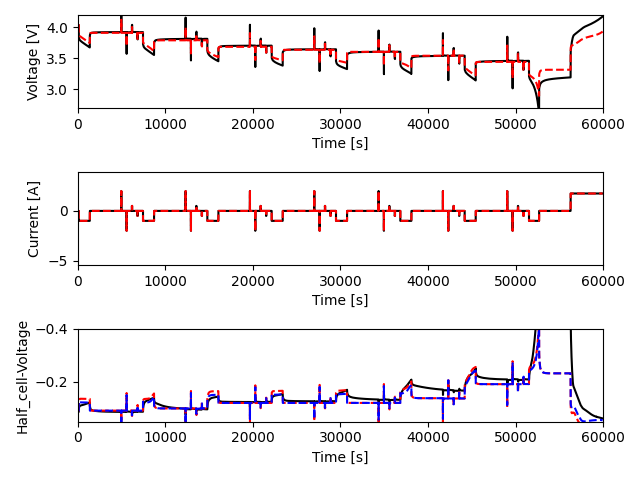

Checking Voltage lengths for RMSE:  2596 3812 RMSE (mV) : 83.43286148549622


In [ ]:
#%matplotlib widget
fig,ax = plt.subplots(3,1)
# plt.title(str(cells[i]) + "Input Data")
ax1 = ax.flat[0]
ax1.plot(t_sim,interp_voltage,'k')
ax1.plot(t,Vt,'r--')
ax1.set_xlim(left=0)
ax1.set_xlabel('Time [s]')
ax1.set_ylabel('Voltage [V]')
ax2 = ax.flat[1]
ax2.plot(t_sim,interp_current,'k')
ax2.plot(t,-I,'r--')
ax2.set_xlim(left=0)
ax2.set_xlabel('Time [s]')
ax2.set_ylabel('Current [A]')
Vneg_elec =sol_0['X-averaged separator electrolyte potential [V]'].entries
#Vneg_surf_pot=sol_0['Negative electrode reaction overpotential [V]'].entries[10,:]
Vneg_surf_pot=sol_0['X-averaged negative electrode surface potential difference [V]'].entries
ax3 = ax.flat[2]
ax3.plot(Exp_data["Test Time"]+start_time_exp-start_time_arbin-tstart,-3.34-0.084+Exp_data["Vneg"],'k')
ax3.plot(t,Vneg_elec,'r--')
ax3.plot(t,-Vneg_surf_pot,'b--')
ax3.set_xlim(left=0)
ax3.set_xlabel('Time [s]')
ax3.set_ylabel('Half_cell-Voltage')
ax3.set_xlim([0,t_end])
ax2.set_xlim([0,t_end])
ax1.set_xlim([0,t_end])
ax1.set_ylim([2.7, 4.2])
ax3.set_ylim([-.05, -0.4])
# ax1.set_ylim([3.5, 4.2])
# ax3.set_ylim([-.05, -0.25])

#ax1.set_ylim([4.05, 4.1])
fig.tight_layout()
plt.show()

#Vt_after1 = np.interp(t_sim, t_after, Vt_after)
#t_after1 = np.interp(t_sim, t_after, t_after)
#voltage_difference_neg=
voltage_difference = (Vt - interp_voltage[range(len(Vt))])*1000
rmse = np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference))
print("Checking Voltage lengths for RMSE: ", len(Vt), len(interp_voltage), "RMSE (mV) :", rmse)

In [ ]:

#spme = pybamm.lithium_ion.SPMe()
spme = pybamm.lithium_ion.DFN()
#parameter_values = pybamm.ParameterValues("OKane2022")
parameter_values = pybamm.ParameterValues("Siegel2022")

# Run Simulation
tend=60000
current_interpolant = pybamm.Interpolant(t_sim[(t_sim>2) * (t_sim<tend)], -interp_current[(t_sim>2) * (t_sim<tend)], pybamm.t)
parameter_values["Current function [A]"] = current_interpolant

fast_solver = pybamm.ScikitsDaeSolver(atol=1e-7, rtol=1e-7) #,mode="fast" ,dt_max=.1
fast_solver=pybamm.CasadiSolver(atol=1e-7, rtol=1e-7 ,mode="safe" ,dt_max=.1)
sim_0 = pybamm.Simulation(spme, parameter_values=parameter_values, solver=fast_solver)
sol_0 = sim_0.solve( t_eval=t_sim[(t_sim>2) * (t_sim<tend)],initial_soc=0.9)

t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
# Q_after = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries

sol_0.plot()
pybamm.plot_voltage_components(sol_0)
# fig,ax = plt.subplots(2,1)
# # plt.title(str(cells[i]) + "Input Data")
# ax1 = ax.flat[0]
# ax1.plot(t_sim,interp_voltage,'k')
# ax1.plot(t,Vt,'r--')
# ax1.set_xlim(left=0)
# ax1.set_xlabel('Time [s]')
# ax1.set_ylabel('Voltage [V]')
# ax2 = ax.flat[1]
# ax2.plot(t_sim,interp_current,'k')
# ax2.plot(t,-I,'r--')
# ax2.set_xlim(left=0)
# ax2.set_xlabel('Time [s]')
# ax2.set_ylabel('Current [A]')
# fig.tight_layout()


ValueError: 'Siegel2022' is not a valid parameter set. Parameter set must be one of:
Ai2020
Chen2020
Chen2020_composite
ECM_Example
Ecker2015
Ecker2015_graphite_halfcell
MSMR_Example
Marquis2019
Mohtat2020
NCA_Kim2011
OKane2022
OKane2022_graphite_SiOx_halfcell
ORegan2022
Prada2013
Ramadass2004
Sulzer2019
Xu2019

interactive(children=(FloatSlider(value=0.0, description='t', max=1034.343437962229, step=10.34343437962229), …

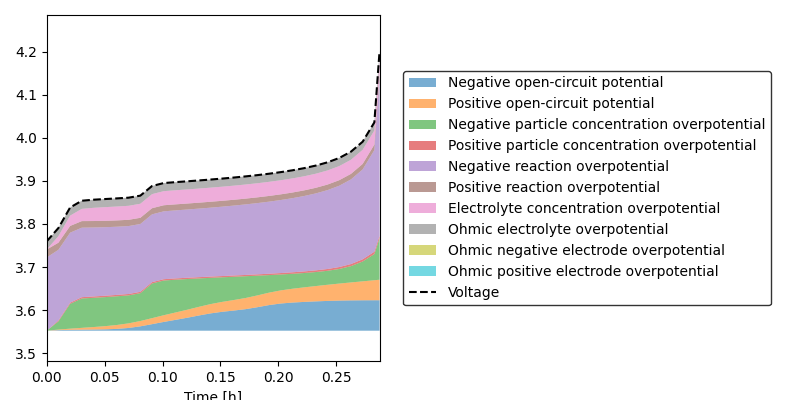

(<Figure size 800x400 with 1 Axes>, <Axes: xlabel='Time [h]'>)

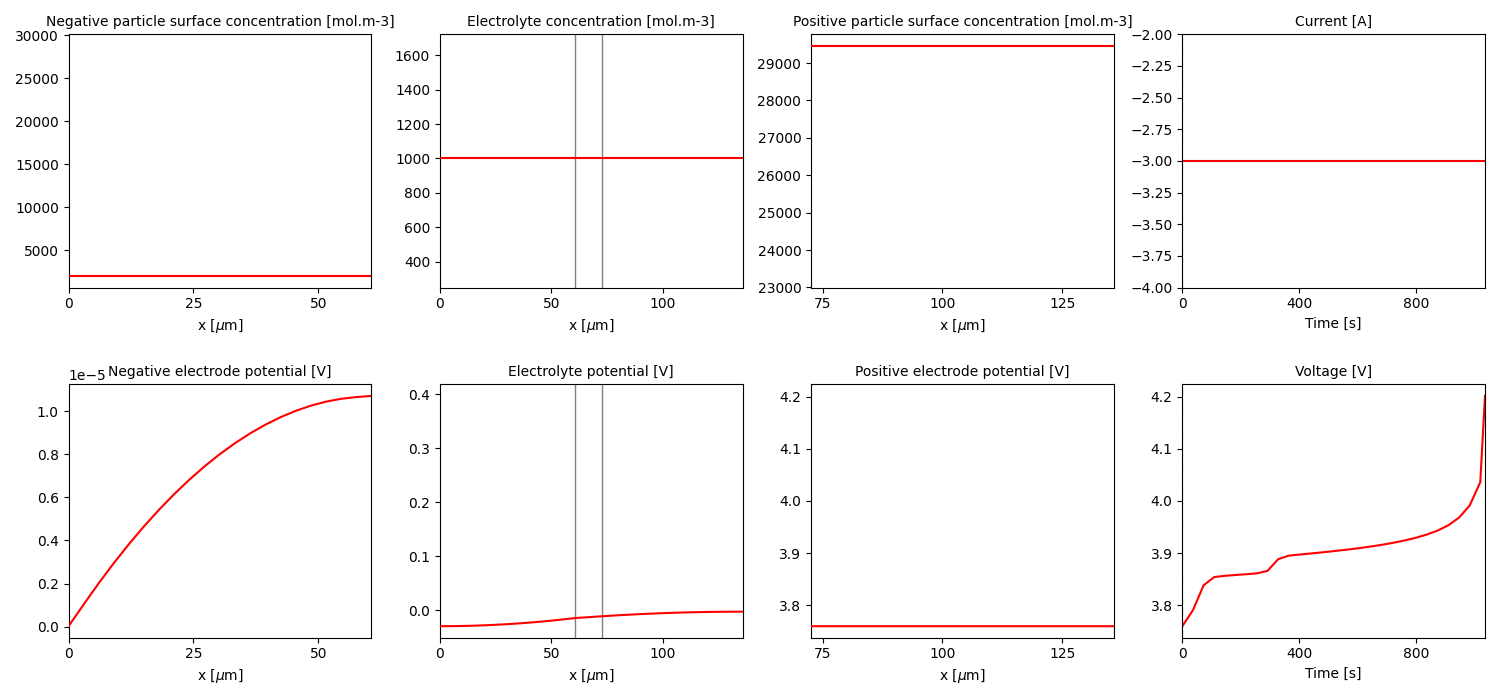

In [ ]:

spme = pybamm.lithium_ion.SPMe()
#spme = pybamm.lithium_ion.DFN()
#parameter_values = pybamm.ParameterValues("OKane2022")
parameter_values = pybamm.ParameterValues("Siegel2022")


parameter_values.update(
    {
        # "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_Siegel,
        #"Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_Siegel,
        #"Positive electrode exchange-current density [A.m-2]": NMC_electrolyte_exchange_current_density_Siegel,
        "Negative electrode exchange-current density [A.m-2]": graphite_electrolyte_exchange_current_density_Siegel,
        
        })  


# Run Simulation
tend=3600
#current_interpolant = pybamm.Interpolant(t_sim[(t_sim>2) * (t_sim<tend)], -interp_current[(t_sim>2) * (t_sim<tend)], pybamm.t)
parameter_values["Current function [A]"] = -3
T=0
parameter_values["Initial temperature [K]"] = 273.15+T
parameter_values["Ambient temperature [K]"] = 273.15+T


fast_solver = pybamm.ScikitsDaeSolver(atol=1e-7, rtol=1e-7) #,mode="fast" ,dt_max=.1
fast_solver=pybamm.CasadiSolver(atol=1e-7, rtol=1e-7 ,mode="safe" ,dt_max=.1)
sim_0 = pybamm.Simulation(spme, parameter_values=parameter_values, solver=fast_solver)
sol_0 = sim_0.solve(t_eval=[0, tend],initial_soc=0.1)

t = sol_0["Time [s]"].entries
I = sol_0["Current [A]"].entries
# Q_after = sol_0['Discharge capacity [A.h]'].entries
Vt = sol_0["Terminal voltage [V]"].entries

sol_0.plot()
pybamm.plot_voltage_components(sol_0, split_by_electrode=True)

In [ ]:
def filtering(hppc_data_raw):

    if 'Weight' in hppc_data_raw.columns:
        hppc_data_raw = hppc_data_raw.drop(['Weight'], axis=1)
    if 'Diff' in hppc_data_raw.columns:
        hppc_data_raw = hppc_data_raw.drop(['Diff'], axis=1)
    if 'Binary' in hppc_data_raw.columns:
        hppc_data_raw = hppc_data_raw.drop(['Binary'], axis=1)

    capacity = 3.5

    # Clipping dataframe to just first block of RPTs
    df = hppc_data_raw.copy()
    df['Time'] = df.Timestamp - df.Timestamp.min()
    df['index_col'] = df.index # Track index position of each dataframe so we're reorganizing the reduced dataframe appropriately

    # Intializing Weight and Binary columns
    df.insert(loc=0, column='Binary', value=0)
    df.insert(loc=0, column='Weight', value=0)

    # Current sign change tracking
    df.loc[df['Current (A)'] > 0, 'Binary'] = 1
    df.loc[df['Current (A)'] < 0, 'Binary'] = 1
    current_sign_change = df[df.Binary.diff() !=0].index.tolist()

    # 50 seconds after current sign change
    for x in range(0, 50):

        csign_change = [i + x for i in current_sign_change]
        df.loc[df.index.isin(csign_change), 'Weight'] = 1

    # 10 seconds before current sign change
    for x in range(0, 10):

        csign_change = [i - x for i in current_sign_change]
        df.loc[df.index.isin(csign_change), 'Weight'] = 1

    # Any non-zero current should not be reduced
    df.loc[df['Current (A)'] != 0, 'Weight'] = 1

    # SOC setting should be sampled at a lower rate
    df.loc[df.DataTag == 0.5, 'Weight'] = 2
    df.loc[df.DataTag == -0.5, 'Weight'] = 2

    df['DateTime'] = pd.to_datetime(df.Time, unit='s')

    # Resampling dataframe sections accordingly
    weight_1_df = df[df.Weight == 1]
    needs_resampling = df[df.Weight == 0]
    soc_setting = df[df.Weight == 2]
    resampled = needs_resampling.resample('10S', on='DateTime').mean()
    resampled_soc_setting = soc_setting.resample('10s', on='DateTime').mean()
    resampled_df = pd.concat([weight_1_df, resampled, resampled_soc_setting])
    resampled_df = resampled_df.sort_values(by=['index_col'])

    pct_reduced = (df.shape[0] - resampled_df.shape[0]) / df.shape[0] * 100
    print('% reduced', pct_reduced)
    return resampled_df

In [ ]:
def execution(inputDict, cells):

    # STEP 1: Inputs for Objective Function
    parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
    spme = pybamm.lithium_ion.SPMe()

    # Objective Function Inputs
    # initial_guess = [4.4 * 10 ** (-15), 5.0 * 10 ** (-15), 4.824 * 10 ** (-6), 1.061 * 10 ** (-6)]
    # lb = [10**(-18), 10**(-18), 10**(-9), 10**(-9)]
    # ub = [10**(-12), 10**(-12), 10**(-3), 10**(-3)]

    # STEP 2: Objective Function
    # 'param0': 7.562822125242107e-13, 'param1': 2.3907778449783082e-14, 'param2': 6.5068308270099e-08, 'param3': 0.0001093915587019561
    # 'param0': 3.2939804080443717e-13, 'param1': 2.4925614356710155e-14, 'param2': 4.006024683515786e-08, 'param3': 5.863856334652709e-05}
    # 'param0': 6.748678940622972e-14, 'param1': 1.0122133310725916e-13, 'param2': 1.3715539078341868e-07, 'param3': 1.2178795378580133e-06
    param0 = 6.748678940622972e-14
    param1 = 1.0122133310725916e-13
    param2 = 1.3715539078341868e-07
    param3 = 1.2178795378580133e-06  
    start_time = time.time()
    rmse = np.zeros(len(cells))
    for i in range(len(cells)):
        t_sim = inputDict[str(cells[i])][0]
        interp_current = inputDict[str(cells[i])][1]
        interp_voltage = inputDict[str(cells[i])][2]
        parameter_values = inputDict[str(cells[i])][3] 
        parameter_values.update(
            {
                "Positive electrode diffusivity [m2.s-1]": NMC_diffusivity_Siegel,
                "Negative electrode diffusivity [m2.s-1]": graphite_diffusivity_Siegel,
                "Positive electrode exchange-current density [A.m-2]": NMC_electrolyte_exchange_current_density_Siegel,
                "Negative electrode exchange-current density [A.m-2]": graphite_electrolyte_exchange_current_density_Siegel,
                
                })           
        
        # Run Simulation
        spme = pybamm.lithium_ion.SPMe()
        sim_0 = pybamm.Simulation(spme, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
        sol_0 = sim_0.solve(
            t_eval=t_sim, 
            inputs = {
            "posDiffusion": param0, 
            "negDiffusion": param1, 
            "posKinetics": param2,
            "negKinetics": param3
            })

        t_after = sol_0["Time [s]"].entries
        I_after = sol_0["Current [A]"].entries
        # Q_after = sol_0['Discharge capacity [A.h]'].entries
        Vt_after = sol_0["Terminal voltage [V]"].entries

        # Analyze Simulation Results

        Vt_after1 = np.interp(t_sim, t_after, Vt_after)
        t_after1 = np.interp(t_sim, t_after, t_after)
        voltage_difference = Vt_after1 - interp_voltage
        rmse[i] = np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference))
        print("Checking Voltage lengths for RMSE: ", len(Vt_after1), len(interp_voltage))
        
        fig,ax = plt.subplots(2,1)
        plt.title(str(cells[i]) + "Optimized Results")
        ax1 = ax.flat[0]
        ax1.plot(t_sim,interp_voltage,'k')
        ax1.plot(t_after,Vt_after,'r--')
        ax1.set_xlim(left=0)
        ax1.set_xlabel('Time [s]')
        ax1.set_ylabel('Voltage [V]')
        ax2 = ax.flat[1]
        ax2.plot(t_sim,interp_current,'k')
        ax2.plot(t_after,-I_after,'r--')
        ax2.set_xlim(left=0)
        ax2.set_xlabel('Time [s]')
        ax2.set_ylabel('Current [A]')
        fig.tight_layout()

        rmseOutput = voltage_difference
        df = pd.DataFrame({"Test Time": t_sim, "Test Voltage": interp_voltage, "Model Time": t_after1, "Model Voltage": Vt_after1, "RMSE": rmseOutput})
        df.to_csv(str(cells[i]) + "RMSE-Time.csv")

        fig,ax = plt.subplots(2,1)
        plt.title(str(cells[i]) + "RMSE-Time")
        ax1 = ax.flat[0]
        ax1.plot(t_sim,rmseOutput*1000,'k')
        ax1.set_xlim(left=0)
        ax1.set_xlabel('Time [s]')
        ax1.set_ylabel('RMSE [mV]')
        fig.tight_layout()

    global rmseAverage
    end_time = time.time()
    single_guess_time = (end_time - start_time)/60 
    rmseAverage = np.sum(rmse)/len(rmse)
    print("time to calculate: ", single_guess_time)
    print("guess parameters and average RMSE: ", param0, param1, param2, param3, rmseAverage)
    return(Vt_after1, interp_voltage,t_after1, I_after)

In [ ]:
###### Revise Start ######
#cells = [['CELL041', 'P25C', '5P0PSI'], ['CELL081', 'P25C', '5P0PSI'], ['CELL016', 'P25C', '5P0PSI']] # cells analyzing together
cells = [['CELL016', 'P25C', '5P0PSI']] # cells analyzing together
#cells = [['CELL016', 'P25C', '5P0PSI']] # cells analyzing together

#cells = [['CELL081', 'P25C', '5P0PSI']]#, ['CELL016', 'P25C', '5P0PSI']] # cells analyzing together

inputDict = {}

for i in range(len(cells)):
    parameter_values = pybamm.ParameterValues(chemistry=pybamm.parameter_sets.Siegel2022)
    spme = pybamm.lithium_ion.SPMe()
    hppc_data_raw = pd.DataFrame()


    # with open('C:\\Users\\rzhgp5\\Downloads\\Misc_UM\\' + str(cells[i]) + ".pickle", "rb") as f:
        # combinedDict = pickle.load(f)
    combinedDict=data
    if cells[i] == ['CELL041', 'P25C', '5P0PSI'] or cells[i] == ['CELL081', 'P25C', '5P0PSI'] or cells[i] == ['CELL016', 'P25C', '5P0PSI']:

        if cells[i] == ['CELL041', 'P25C', '5P0PSI']:
            temperature = 25
            C_n_init = 4.0352
            C_p_init = 5.495
            x_init = 0.8613 # x0 or x100 depending on starting at 0 SOC or 1 SOC
            y_init = 0.3096 # use 0 if a negative value # y0 or y100 depending on starting at 0 SOC or 1 SOC

        elif cells[i] == ['CELL081', 'P25C', '5P0PSI']:
            temperature = 25
            C_n_init = 4.0458
            C_p_init = 5.4828
            x_init = 0.861 # x0 or x100 depending on starting at 0 SOC or 1 SOC
            y_init = 0.3083 # use 0  if a negati if a negative value # y0 or y100 depending on starting at 0 SOC or 1 SOC

        elif cells[i] == ['CELL016', 'P25', '5P0PSI']:
            temperature = 25
            C_n_init = 4.0846
            C_p_init = 5.5243
            x_init = 0.8658 # x0 or x100 depending on starting at 0 SOC or 1 SOC
            y_init = 0.30638 # use 0  value # y0 or y100 depending on starting at 0 SOC or 1 SOC

        count = 0
        for key, value in combinedDict.items():
            if value[0] == 5 or value[0] == 3 or value[0] == 1:
                # if count >0:
                count += 1
                df = pd.DataFrame(value[1])
                hppc_data_raw = pd.concat([hppc_data_raw, df], ignore_index=True)
                # if count > 8:
                #     break
                
            # elif value[0] == -5 or value[0] == -3:
            #     break

        hppc_data_raw = hppc_data_raw.sort_values(by = ['Timestamp', 'Test Time (s)'])
        if max(hppc_data_raw['Potential (V)']) >4.210: 
            raise ("Warning >10mV overshoot at initial OCV")
            
        #print(max(hppc_data_raw["Potential (V)"]))
        hppc_data_raw.loc[hppc_data_raw['Potential (V)'] > 4.2, 'Potential (V)'] = 4.2
        index_to_drop = hppc_data_raw[hppc_data_raw["Potential (V)"] < 2.7].index.min()
        hppc_data_raw = hppc_data_raw.loc[:index_to_drop - 1]
        hppc_data_raw = filtering(hppc_data_raw)

        # Experimental data
        hppc_data = hppc_data_raw.dropna(subset=['Current (A)', 'Potential (V)', 'Time'])
        hppc_data = hppc_data.rename(columns={'Current (A)': 'Current [A]', 'Potential (V)': 'Voltage [V]', 'Time': 'Time [s]'})
        data_time = hppc_data['Time [s]'] - hppc_data['Time [s]'][0]
        data_current = hppc_data['Current [A]'].values
        data_voltage= hppc_data['Voltage [V]'].values

        if cells[i] == ['CELL081', 'P25C', '5P0PSI']:
            index = 5800*2
            data_voltage = data_voltage[index:]
            data_current = data_current[index:]
            data_time = data_time[index:]
            data_time = data_time.reset_index(drop=True)
            data_time = data_time - data_time[0]

        elif cells[i] == ['CELL041', 'P25C', '5P0PSI']:
            index = 5800*2
            l = index
            data_voltage = data_voltage[index:]
            data_current = data_current[index:]
            data_time = data_time[index:]
            data_time = data_time.reset_index(drop=True)
            data_time = data_time - data_time[0]  

        elif cells[i] == ['CELL016', 'P25C', '5P0PSI']:
            index = 5800*2+2800
            l = index
            data_voltage = data_voltage[index:]
            data_current = data_current[index:]
            data_time = data_time[index:]
            data_time = data_time.reset_index(drop=True)
            data_time = data_time - data_time[0]

        ###### Revise End ######

        #interpolation
        t_sim = np.arange(0,data_time.iloc[-1],0.1)
        interp_current = np.interp(t_sim, data_time, data_current, left=None, right=None, period=None)
        interp_voltage = np.interp(t_sim, data_time, data_voltage, left=None, right=None, period=None)   
        # t_sim = np.array(list(data_time))
        # interp_current = np.array(list(data_current))
        # interp_voltage = np.array(list(data_voltage))
        
        parameter_values.update({"Lower voltage cut-off [V]": 2.7, "Upper voltage cut-off [V]": 4.2}, check_already_exists=False)
        param = spme.param
        parameter_values.update(
            {
                "Maximum concentration in positive electrode [mol.m-3]":	31927.3,
                "Maximum concentration in negative electrode [mol.m-3]":	29637,
                },check_already_exists=False,)    

        C_n_init = 4.0458 
        C_p_init = 5.4828
        x_init = 0.861
        y_init = 0.3083
        eps_n_init = parameter_values.evaluate(C_n_init*3600/(param.n.L * param.n.prim.c_max * param.F* param.A_cc))
        eps_p_init = parameter_values.evaluate(C_p_init*3600/(param.p.L * param.p.prim.c_max * param.F* param.A_cc))
        cs_n_init = parameter_values.evaluate(x_init* param.n.prim.c_max)
        cs_p_init = parameter_values.evaluate(y_init* param.p.prim.c_max)

        # Updating parameters for initialization
        parameter_values.update(
            {
                "Negative electrode active material volume fraction": eps_n_init,
                "Positive electrode active material volume fraction": eps_p_init,
                "Initial concentration in negative electrode [mol.m-3]":cs_n_init,
                "Initial concentration in positive electrode [mol.m-3]":cs_p_init,
                "Initial temperature [K]": 273.15+25,
                "Ambient temperature [K]": 273.15+25,
            },check_already_exists=False,)

        Vmin = 2.7
        Vmax = 4.2
        esoh_model = pybamm.lithium_ion.ElectrodeSOH()
        esoh_sim = pybamm.Simulation(esoh_model, parameter_values=parameter_values)
        esoh_solver = pybamm.lithium_ion.ElectrodeSOHSolver(parameter_values, param)
        Cn = parameter_values.evaluate(param.n.cap_init)
        Cp = parameter_values.evaluate(param.p.cap_init)
        eps_n = parameter_values["Negative electrode active material volume fraction"]
        eps_p = parameter_values["Positive electrode active material volume fraction"]
        c_n_max = parameter_values.evaluate(param.n.prim.c_max)
        c_p_max = parameter_values.evaluate(param.p.prim.c_max)
        n_Li_init = parameter_values.evaluate(param.n_Li_particles_init)

        esoh_sol = esoh_sim.solve(
            [0],
            inputs={"V_min": Vmin, "V_max": Vmax, "C_n": Cn, "C_p": Cp, "n_Li": n_Li_init},
            solver=pybamm.AlgebraicSolver(),)

        x100=esoh_sol["x_100"].data[0]
        y100=esoh_sol["y_100"].data[0]
        x0=esoh_sol["x_0"].data[0]
        y0=esoh_sol["y_0"].data[0]
        
        timescale = parameter_values.evaluate(spme.timescale)
        # discharge is positive current in PyBaMM
        current_interpolant = pybamm.Interpolant(t_sim, -interp_current, timescale * pybamm.t)
        parameter_values["Current function [A]"] = current_interpolant
        parameter_values.update({"Lower voltage cut-off [V]": 2.7, "Upper voltage cut-off [V]": 4.22}, check_already_exists=False)

        sim_0 = pybamm.Simulation(spme, parameter_values=parameter_values, solver=pybamm.CasadiSolver("safe"))
        sol_0 = sim_0.solve(t_eval=t_sim)

        t = sol_0["Time [s]"].entries
        I = sol_0["Current [A]"].entries
        Q = sol_0['Discharge capacity [A.h]'].entries
        Vt = sol_0["Terminal voltage [V]"].entries

        #print("Voltage Comparison for " + str(cells[i]) + ":", interp_voltage[0], Vt[0], abs(interp_voltage[0]-Vt[0]))

        fig,ax = plt.subplots(2,1)
        plt.title(str(cells[i]) + "Input Data")
        ax1 = ax.flat[0]
        ax1.plot(t_sim,interp_voltage,'k')
        ax1.plot(t,Vt,'r--')
        ax1.set_xlim(left=0)
        ax1.set_xlabel('Time [s]')
        ax1.set_ylabel('Voltage [V]')
        ax2 = ax.flat[1]
        ax2.plot(t_sim,interp_current,'k')
        ax2.plot(t,-I,'r--')
        ax2.set_xlim(left=0)
        ax2.set_xlabel('Time [s]')
        ax2.set_ylabel('Current [A]')
        fig.tight_layout()

        inputDict.update({str(cells[i]): [t_sim, interp_current, interp_voltage, parameter_values]})

cells = [['CELL016', 'P25C', '5P0PSI']] 
#cells = [['CELL081', 'P25C', '5P0PSI']] 

v_model, v_test, t_model, current_model =  execution(inputDict, cells)

TypeError: ParameterValues.__init__() missing 1 required positional argument: 'values'

15.085432652766753

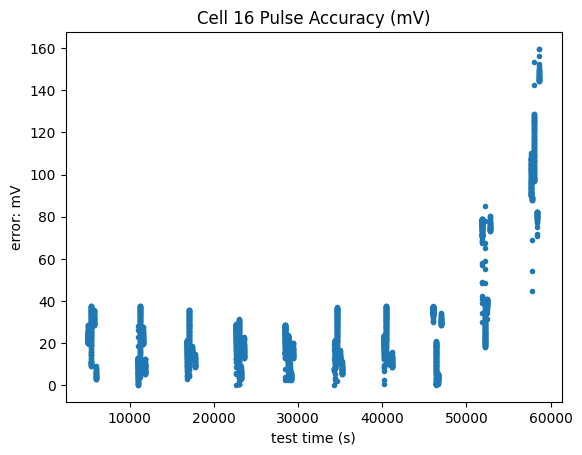

In [ ]:
#find pulse Accuracy:
threshold_low = -1.2
threshold_high = 1.2
sign_index = []

condition_model = (current_model < threshold_low) | (current_model > threshold_high)
sign_index_model = np.where(condition_model)[0]
Vpulse_model = v_model[sign_index_model]
Vpulse_test = v_test[sign_index_model]
t = t_model[sign_index_model]

error = [(Vpulse_model[i] - Vpulse_test[i])**2.0 for i in range(len(Vpulse_model))]
error = [np.sqrt(i) * 1000 for i in error]
RMSE = np.sqrt(np.mean(error))

plt.plot(t,error,'.')
plt.xlabel('test time (s)')
plt.ylabel('error: mV')
plt.title("Cell 16 Pulse Accuracy (mV)") 

error_whole = [((v_model[i] - v_test[i])**2.0)**0.5*1000 for i in range(len(v_test))]
RMSE = np.mean(error_whole[:49999])
# plt.plot(t_model[:49999],error_whole[:49999])
# plt.xlabel('test time (s)')
# plt.ylabel('error: mV')
# RMSE
if not cell_output_dict: 
    cell_output_dict= {}
cell_output_dict["cell16"] = [v_test,v_model,t_model, Vpulse_model, Vpulse_test,t,error ] 
RMSE

In [ ]:
hppc_data

,Weight,Binary,Timestamp,Test Time (s),Current [A],Voltage [V],DataTag,Discharge Capacity (Ah),Time [s],index_col,DateTime
0,1.0,0.0,1.672783e+09,0.0,0.00000,3.34390,0.0,0.00000,0.0,0.0,1970-01-01 00:00:00.000000000
1,1.0,0.0,1.672783e+09,0.1,0.00000,3.34390,0.0,0.00000,0.1,1.0,1970-01-01 00:00:00.099999904
2,1.0,1.0,1.672783e+09,0.1,0.99980,3.44490,0.0,0.00000,0.1,2.0,1970-01-01 00:00:00.099999904
3,1.0,1.0,1.672783e+09,0.2,0.99980,3.44490,0.0,0.00000,0.2,3.0,1970-01-01 00:00:00.200000047
4,1.0,1.0,1.672783e+09,0.4,1.00000,3.45660,0.0,0.00000,0.4,4.0,1970-01-01 00:00:00.400000095
...,...,...,...,...,...,...,...,...,...,...,...
1970-01-01 22:38:40,2.0,1.0,1.672865e+09,81524.9,-0.30012,2.72963,-0.5,0.18580,81524.9,138910.5,NaT
1970-01-01 22:38:50,2.0,1.0,1.672865e+09,81534.9,-0.30003,2.72162,-0.5,0.18663,81534.9,138920.5,NaT
1970-01-01 22:39:00,2.0,1.0,1.672865e+09,81544.9,-0.30010,2.71349,-0.5,0.18749,81544.9,138930.5,NaT
1970-01-01 22:39:10,2.0,1.0,1.672865e+09,81554.9,-0.30006,2.70524,-0.5,0.18831,81554.9,138940.5,NaT


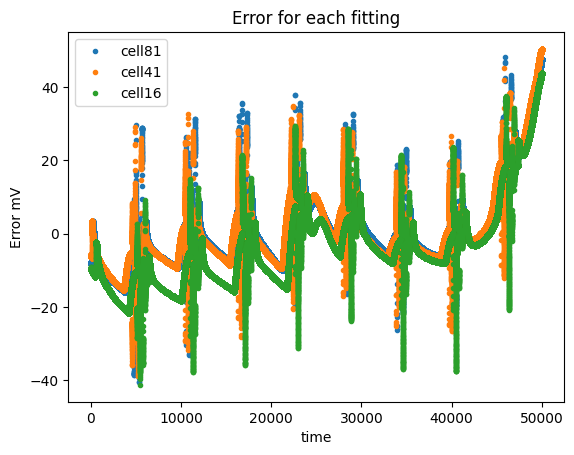

In [ ]:
for cell in cell_output_dict: 
    y = (cell_output_dict[cell][0] - cell_output_dict[cell][1])*1000
    x = cell_output_dict[cell][2]

    y = y[:500000]
    x = x[:500000]
    plt.plot(x,y,'.',label=cell)
plt.xlabel('time')
plt.ylabel('Error mV')
plt.title('Error for each fitting')
plt.legend()
plt.show()

In [ ]:
Vt_after1 = np.interp(t_sim, t, Vt)
t_after1 = np.interp(t_sim, t, t)
voltage_difference = Vt_after1 - interp_voltage
len(t_after1), len(Vt_after1), len( 
#rmse[i] = np.sqrt((np.sum(voltage_difference**2))/len(voltage_difference))

(664953, 664953)

In [ ]:
#Let's see if this black Screen's again. 
len(Vt), len(interp_voltage)
#Calculate RMSE: 
error = [(Vt[i] - interp_voltage[i])**2.0 for i in range(len(Vt))]
RMSE = np.sqrt(np.mean(error))
print(round(RMSE*1000,1), "mV error at C/3")

69.8 mV error at C/3


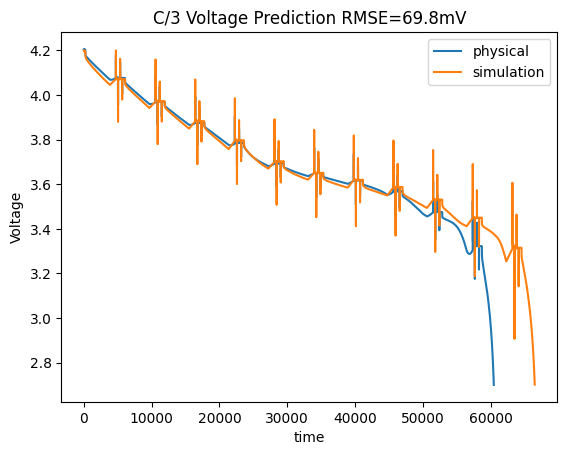

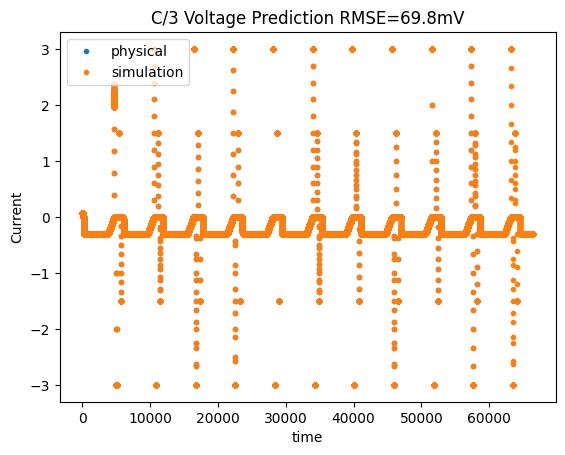

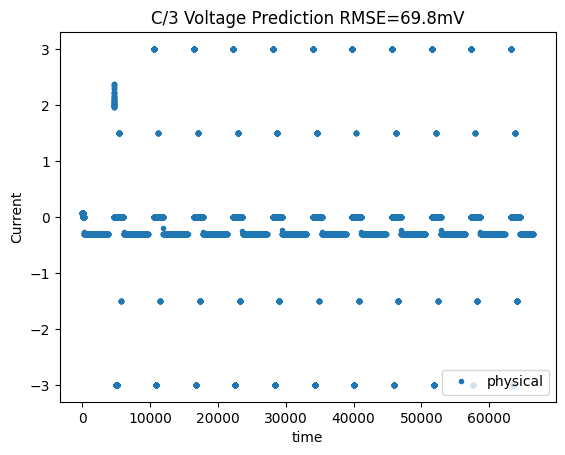

In [ ]:
import matplotlib.pyplot as plt
plt.plot(t,Vt, label='physical')
plt.plot(t_sim, interp_voltage, label='simulation')
plt.xlabel('time')
plt.ylabel("Voltage")
plt.title("C/3 Voltage Prediction RMSE={}mV".format(round(RMSE*1000,1)))
plt.legend()
plt.show()

#min(df["Potential (V)"])
import matplotlib.pyplot as plt
plt.plot(t,-I, '.',label='physical',)
plt.plot(t_sim, interp_current ,'.',label='simulation')
plt.xlabel('time')
plt.ylabel("Current")
plt.title("C/3 Voltage Prediction RMSE={}mV".format(round(RMSE*1000,1)))
plt.legend()
plt.show()

plt.plot(data_time,data_current, '.',label='physical',)
plt.xlabel('time')
plt.ylabel("Current")
plt.title("C/3 Voltage Prediction RMSE={}mV".format(round(RMSE*1000,1)))
plt.legend()
plt.show()

In [ ]:
len(interp_voltage), len(Vt)
len(t), len(t_sim)

(604621, 664953)

In [ ]:
#find pulse Accuracy:
threshold_low = -1.2
threshold_high = 1.2
sign_index = []

condition_model = (I < threshold_low) | (I > threshold_high)
sign_index_model = np.where(condition_model)[0]
condition_test = (interp_current < threshold_low) | (interp_current > threshold_high)
sign_index_test = np.where(condition_test)[0]
Vpulse_model = interp_voltage[sign_index_model]
Vpulse_test = interp_voltage[sign_index_test]
len(Vpulse_test), len(Vpulse_model) 

(3030, 2753)

In [ ]:
cell_num.append(cells[0])
cell_errors.append(RMSE)
cell_voltage.append(Vt)
cell_prediction.append(interp_voltage)
cell_v0.append(Vt[0])

In [ ]:
cell_output_dict = {}